In [1]:
%pip install -q ultralytics pyyaml matplotlib pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
import json
import random
import shutil
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

kaggle_root = Path('/kaggle/input/datasets')
local_root = Path.cwd() / 'dataset'
if kaggle_root.exists():
    candidates = [
        path for path in [kaggle_root, *kaggle_root.rglob('*')]
        if path.is_dir() and (path / 'train' / '_annotations.coco.json').exists()
    ]
    if not candidates:
        raise FileNotFoundError('COCO dataset with train/_annotations.coco.json was not found under /kaggle/input/datasets')
    DATASET_DIR = candidates[0]
    YOLO_DIR = Path('/kaggle/working/dataset_yolo')
    RUNS_DIR = Path('/kaggle/working/runs')
elif (local_root / 'train' / '_annotations.coco.json').exists():
    DATASET_DIR = local_root
    YOLO_DIR = DATASET_DIR.parent / 'dataset_yolo'
    RUNS_DIR = DATASET_DIR.parent / 'runs'
else:
    DATASET_DIR = Path(r'e:/Me/Porject/Plastic Waste Detection on Cox_s Bazar Sea Beach.coco/dataset')
    YOLO_DIR = DATASET_DIR.parent / 'dataset_yolo'
    RUNS_DIR = DATASET_DIR.parent / 'runs'

SPLITS = {'train': 'train', 'val': 'valid', 'test': 'test'}
print('COCO dataset:', DATASET_DIR)
print('YOLO dataset:', YOLO_DIR)
print('Training runs:', RUNS_DIR)

COCO dataset: /kaggle/input/datasets/rakib730/plastic
YOLO dataset: /kaggle/working/dataset_yolo
Training runs: /kaggle/working/runs


In [15]:
with open(DATASET_DIR / 'train' / '_annotations.coco.json', encoding='utf-8') as f:
    train_coco = json.load(f)
used_ids = {ann['category_id'] for ann in train_coco['annotations']}
categories = [cat for cat in sorted(train_coco['categories'], key=lambda item: item['id']) if cat['id'] in used_ids]
category_id_to_yolo = {cat['id']: index for index, cat in enumerate(categories)}
class_names = [cat['name'] for cat in categories]
print('Number of classes:', len(class_names))
print(class_names)
for split_dir in SPLITS.values():
    with open(DATASET_DIR / split_dir / '_annotations.coco.json', encoding='utf-8') as f:
        coco = json.load(f)
    print(split_dir, len(coco['images']), 'images,', len(coco['annotations']), 'annotations')

Number of classes: 14
['bag', 'bottle', 'bottle_cap', 'cup', 'fishing_item', 'net', 'others', 'packet', 'polythene', 'rope', 'spoon', 'straw', 'sunglass', 'toy']
train 3367 images, 5633 annotations
valid 414 images, 766 annotations
test 414 images, 908 annotations


In [16]:
def convert_split(coco_dir, output_split):
    with open(coco_dir / '_annotations.coco.json', encoding='utf-8') as f:
        coco = json.load(f)
    image_out = YOLO_DIR / 'images' / output_split
    label_out = YOLO_DIR / 'labels' / output_split
    image_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)
    anns_by_image = {}
    for ann in coco['annotations']:
        anns_by_image.setdefault(ann['image_id'], []).append(ann)
    image_count = 0
    box_count = 0
    for image in coco['images']:
        source = coco_dir / image['file_name']
        if not source.exists():
            raise FileNotFoundError(source)
        shutil.copy2(source, image_out / source.name)
        width, height = float(image['width']), float(image['height'])
        lines = []
        for ann in anns_by_image.get(image['id'], []):
            if ann['category_id'] not in category_id_to_yolo:
                continue
            x, y, box_width, box_height = map(float, ann['bbox'])
            x1, y1 = max(0, min(x, width)), max(0, min(y, height))
            x2, y2 = max(0, min(x + box_width, width)), max(0, min(y + box_height, height))
            if x2 <= x1 or y2 <= y1:
                continue
            values = [category_id_to_yolo[ann['category_id']], (x1 + x2) / 2 / width, (y1 + y2) / 2 / height, (x2 - x1) / width, (y2 - y1) / height]
            lines.append(' '.join([str(values[0])] + [f'{value:.6f}' for value in values[1:]]))
        (label_out / f'{source.stem}.txt').write_text('\n'.join(lines), encoding='utf-8')
        image_count += 1
        box_count += len(lines)
    return image_count, box_count

summary = {}
for yolo_split, coco_split in SPLITS.items():
    summary[yolo_split] = convert_split(DATASET_DIR / coco_split, yolo_split)
print(summary)

{'train': (3367, 5631), 'val': (414, 765), 'test': (414, 907)}


In [17]:
data_yaml = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names),
    'names': class_names,
}
DATA_YAML = YOLO_DIR / 'data.yaml'
DATA_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding='utf-8')
print(DATA_YAML.read_text(encoding='utf-8'))

path: /kaggle/working/dataset_yolo
train: images/train
val: images/val
test: images/test
nc: 14
names:
- bag
- bottle
- bottle_cap
- cup
- fishing_item
- net
- others
- packet
- polythene
- rope
- spoon
- straw
- sunglass
- toy



In [18]:
for split in ('train', 'val', 'test'):
    images = list((YOLO_DIR / 'images' / split).glob('*.jpg'))
    labels = list((YOLO_DIR / 'labels' / split).glob('*.txt'))
    assert len(images) == len(labels), f'{split}: image/label mismatch'
    for label_file in random.sample(labels, min(10, len(labels))):
        for line in label_file.read_text(encoding='utf-8').splitlines():
            values = line.split()
            assert len(values) == 5
            class_id, *box = map(float, values)
            assert 0 <= class_id < len(class_names)
            assert all(0 <= value <= 1 for value in box)
print('Conversion and label sanity check passed.')

Conversion and label sanity check passed.


## Train YOLO11

প্রথমে `epochs=50` দিয়ে চালান। GPU থাকলে `batch` বাড়াতে পারেন।

In [20]:
import torch
from pathlib import Path
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
print('Device:', torch.cuda.get_device_name(0) if device == 0 else 'CPU')

# Kaggle input is read-only, so all training outputs must go to /kaggle/working.
RUNS_DIR = Path('/kaggle/working/runs') if Path('/kaggle').exists() else RUNS_DIR
RUNS_DIR.mkdir(parents=True, exist_ok=True)
print('Training runs:', RUNS_DIR)

model = YOLO('yolo11n.pt')
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16 if device == 0 else 4,
    device=device,
    workers=0,
    patience=20,
    project=str(RUNS_DIR),
    name='plastic_waste_yolo11n',
    exist_ok=True,
    pretrained=True,
    plots=True,
)

Device: Tesla T4
Training runs: /kaggle/working/runs
Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosa

In [22]:
from pathlib import Path

RUNS_DIR = Path('/kaggle/working/runs') if Path('/kaggle').exists() else RUNS_DIR
BEST_WEIGHTS = RUNS_DIR / 'plastic_waste_yolo11n' / 'weights' / 'best.pt'
if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(f'Best weights not found. Complete the training cell first: {BEST_WEIGHTS}')
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data=str(DATA_YAML), split='test', imgsz=640, device=device)
print('mAP50-95:', metrics.box.map)
print('mAP50:', metrics.box.map50)

Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2128.6±465.6 MB/s, size: 93.9 KB)
val: Scanning /kaggle/working/dataset_yolo/labels/test.cache... 414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 414/414 173.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 6.0it/s 4.3s0.1s
                   all        414        907      0.792      0.597      0.664      0.388
                   bag         14         17      0.662      0.412      0.391      0.237
                bottle         27         33      0.988      0.636      0.672      0.466
            bottle_cap         29         30      0.842        0.8      0.905      0.437
                   cup         47         61      0.729      0.557      0.596      0.355
          fishing_item       


image 1/1 /kaggle/working/dataset_yolo/images/test/WhatsApp-Image-2025-10-19-at-22_28_43_826266c6_jpg.rf.cd3cd0ddacd8aa6f9dd0758d3952afdb.jpg: 640x640 2 packets, 1 polythene, 1 spoon, 10.7ms
Speed: 2.1ms preprocess, 10.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


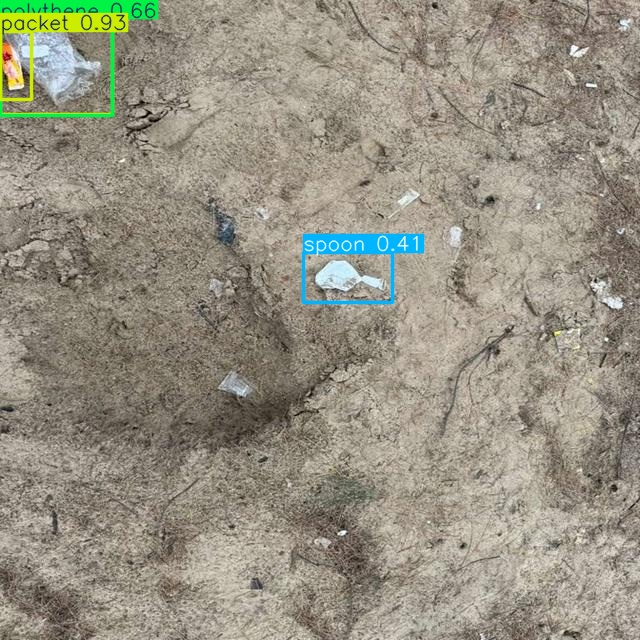

Prediction saved at: /kaggle/working/runs/detect/predict/WhatsApp-Image-2025-10-19-at-22_28_43_826266c6_jpg.rf.cd3cd0ddacd8aa6f9dd0758d3952afdb.jpg


In [25]:
test_image = random.choice(list((YOLO_DIR / 'images' / 'test').glob('*.jpg')))
prediction = best_model.predict(source=str(test_image), conf=0.25, save=True, device=device)
annotated_image = Path(prediction[0].save_dir) / test_image.name
display(Image.open(annotated_image))
print('Prediction saved at:', annotated_image)

In [26]:
from pathlib import Path
import os
import shutil

if 'BEST_WEIGHTS' not in globals():
    RUNS_DIR = Path('/kaggle/working/runs') if Path('/kaggle').exists() else RUNS_DIR
    BEST_WEIGHTS = RUNS_DIR / 'plastic_waste_yolo11n' / 'weights' / 'best.pt'

if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(f'Best model not found: {BEST_WEIGHTS}')

if Path('/kaggle').exists():
    MODEL_DIR = Path('/kaggle/working')
else:
    MODEL_DIR = Path.cwd()

MODEL_FILE = MODEL_DIR / 'plastic_waste_yolo11n_best.pt'
shutil.copy2(BEST_WEIGHTS, MODEL_FILE)
assert MODEL_FILE.exists() and MODEL_FILE.stat().st_size > 0
print('Model saved:', MODEL_FILE)
print('Size (MB):', round(MODEL_FILE.stat().st_size / (1024 * 1024), 2))

if Path('/kaggle').exists():
    from IPython.display import FileLink, display
    os.chdir(MODEL_DIR)
    display(FileLink(MODEL_FILE.name, result_html_prefix='Download model: '))

Model saved: /kaggle/working/plastic_waste_yolo11n_best.pt
Size (MB): 5.22


/kaggle/working/plastic_waste_yolo11n_best.pt